# Project 7 — Task 1: Training DDPMs with Linear vs Cosine Schedules
**Group 4** — Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

Trains two conditional denoising diffusion models (DDPM) on the custom 20x20 MNIST, following Tutorial 9.3: one with the tutorial's **linear** beta schedule and one with our **cosine** beta schedule (Nichol & Dhariwal, 2021). Both use an identical conditional U-Net, epochs, optimiser and seed, so the noise schedule is the only difference. Checkpoints and loss/time logs are saved for `main_report.ipynb`.

## Setup, data, schedules, model

In [1]:
# --- Standard stack, matching the Week 9 diffusion tutorial -------------------
import os, math, time, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- Reproducibility ---------------------------------------------------------
SEED = 680
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# --- Hardware (the brief requires .to(device)) -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device = {device}")

# --- Shared experiment constants ---------------------------------------------
TIMESTEPS   = 1000   # diffusion length T used for TRAINING both models
IMG_SIZE    = 20     # the custom dataset is 20x20 (not 28x28)
CHANNELS    = 1
NUM_CLASSES = 10

PyTorch 2.13.0+cu126 | device = cuda


In [2]:
# ---------------------------------------------------------------------------
# Load the provided custom MNIST (dict of tensors: 20x20, values in [0,1]) and
# rescale to [-1, 1] exactly as the tutorial does (x*2 - 1), so the forward
# process ends at ~N(0, I). We keep the whole training set on the GPU and draw
# batches by indexing: with 60k tiny 20x20 images this removes the DataLoader
# bottleneck and keeps training GPU-bound.
# ---------------------------------------------------------------------------
DATA_PATH = next((p for p in ["mnist_custom.pt", "mnist_custom-1.pt"]
                  if os.path.exists(p)), "mnist_custom.pt")
BATCH_SIZE = 256

blob = torch.load(DATA_PATH, map_location="cpu")
train_x = (blob["train_images"].float() * 2 - 1).to(device)   # (60000,1,20,20) in [-1,1]
train_y = blob["train_labels"].long().to(device)
test_x  = (blob["test_images"].float() * 2 - 1).to(device)
test_y  = blob["test_labels"].long().to(device)
N_TRAIN = train_x.shape[0]
print("train:", tuple(train_x.shape), "range [%.1f, %.1f]" % (train_x.min(), train_x.max()))

def iterate_batches(generator):
    """Yield (x0, labels) batches by shuffling GPU-resident indices each epoch."""
    perm = torch.randperm(N_TRAIN, generator=generator, device=device)
    for i in range(0, N_TRAIN - BATCH_SIZE + 1, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        yield train_x[idx], train_y[idx]

train: (60000, 1, 20, 20) range [-1.0, 1.0]


In [3]:
# ---------------------------------------------------------------------------
# The two schedules under test. `linear_beta_schedule` is the Tutorial 9.3
# baseline. `cosine_beta_schedule` is our implementation of the Nichol &
# Dhariwal (2021) cosine schedule: it defines the cumulative product alpha_bar
# through a squared-cosine and derives beta_t from it, adding noise more slowly
# so more signal is preserved in the early/most steps.
# ---------------------------------------------------------------------------
def extract(a, t, x_shape):
    """Gather schedule coefficients at timesteps t and reshape for broadcasting."""
    out = a.gather(-1, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """Nichol & Dhariwal (2021): alpha_bar(t) = cos(((t/T)+s)/(1+s) * pi/2)^2,
    normalised so alpha_bar(0)=1; beta_t = 1 - alpha_bar(t)/alpha_bar(t-1),
    clipped to (0, 0.999] for numerical stability."""
    steps = timesteps + 1
    t = torch.linspace(0, timesteps, steps) / timesteps
    alpha_bar = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
    alpha_bar = alpha_bar / alpha_bar[0]
    betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
    return torch.clip(betas, 1e-8, 0.999)

def build_schedule(kind, timesteps=TIMESTEPS):
    """Return a dict of the tensors DDPM needs (all on device) for a schedule."""
    betas = (linear_beta_schedule(timesteps) if kind == "linear"
             else cosine_beta_schedule(timesteps)).to(device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return {"betas": betas, "alphas": alphas, "alpha_bars": alpha_bars, "T": timesteps}

def q_sample(x0, t, alpha_bars, noise=None):
    """Forward diffusion: add t steps of noise to x0 in closed form."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = torch.sqrt(extract(alpha_bars, t, x0.shape))
    sqrt_1m_ab = torch.sqrt(extract(1 - alpha_bars, t, x0.shape))
    return sqrt_ab * x0 + sqrt_1m_ab * noise

In [4]:
# ---------------------------------------------------------------------------
# Conditional U-Net eps-predictor, identical in spirit to Tutorial 9.3. Two
# pooling levels take 20x20 -> 10x10 -> 5x5 and back. The timestep and class
# embeddings are summed and injected (as 1x1 conv biases) at every stage.
# ---------------------------------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNet_cond(nn.Module):
    def __init__(self, ch=32, n_classes=NUM_CLASSES, timesteps=TIMESTEPS):
        super().__init__()
        self.timesteps = timesteps
        self.enc1 = ConvBlock(CHANNELS, ch)
        self.enc2 = ConvBlock(ch, ch * 2)
        self.bot  = ConvBlock(ch * 2, ch * 2)
        self.dec2 = ConvBlock(ch * 2 + ch * 2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        self.final = nn.Conv2d(ch, CHANNELS, 1)
        self.time_mlp = nn.Sequential(nn.Linear(1, ch), nn.ReLU(), nn.Linear(ch, ch))
        self.class_emb = nn.Embedding(n_classes, ch)
        self.to_e1 = nn.Conv2d(ch, ch, 1);     self.to_e2 = nn.Conv2d(ch, ch * 2, 1)
        self.to_b  = nn.Conv2d(ch, ch * 2, 1);  self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)
        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode="nearest")

    def forward(self, x, t, y):
        t = t.float().unsqueeze(-1) / self.timesteps
        cond = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1) + \
               self.class_emb(y).unsqueeze(-1).unsqueeze(-1)
        e1 = self.enc1(x) + self.to_e1(cond)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond)
        b  = self.bot(self.pool(e2)) + self.to_b(cond)
        d2 = torch.cat([self.upsample(b), e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond)
        d1 = torch.cat([self.upsample(d2), e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond)
        return self.final(d1)

In [5]:
# ---------------------------------------------------------------------------
# Respaced ancestral DDPM sampler. To sample in `num_steps` (<= T), we pick an
# evenly spaced subsequence of the original timesteps and recompute the DDPM
# posterior for that subsequence (the standard respacing of Nichol & Dhariwal /
# strided DDPM). The eps-network still receives the ORIGINAL timestep index it
# was trained on. num_steps == T reproduces the full tutorial sampler.
# ---------------------------------------------------------------------------
def respaced_constants(alpha_bars_full, num_steps, T=TIMESTEPS):
    idx = torch.linspace(0, T - 1, num_steps).long().to(device)     # chosen original t's
    ab = alpha_bars_full[idx]
    ab_prev = torch.cat([torch.ones(1, device=device), ab[:-1]])
    betas_r = 1 - ab / ab_prev
    return idx, betas_r, (1 - betas_r), ab

@torch.no_grad()
def sample_conditional(model, schedule, labels, num_steps=None, seed=1337):
    """Conditional generation for a batch of class labels using `num_steps`
    reverse steps. Returns images in [0, 1]."""
    model.eval()
    T = schedule["T"]
    num_steps = T if num_steps is None else num_steps
    idx, betas_r, alphas_r, ab_r = respaced_constants(schedule["alpha_bars"], num_steps, T)
    g = torch.Generator(device=device).manual_seed(seed)
    x = torch.randn(labels.shape[0], CHANNELS, IMG_SIZE, IMG_SIZE,
                    generator=g, device=device)
    for i in reversed(range(num_steps)):
        t_model = torch.full((labels.shape[0],), int(idx[i]), device=device, dtype=torch.long)
        beta, alpha, abar = betas_r[i], alphas_r[i], ab_r[i]
        eps = model(x, t_model, labels)
        mean = (x - beta / torch.sqrt(1 - abar) * eps) / torch.sqrt(alpha)
        if i > 0:
            noise = torch.randn(x.shape, generator=g, device=device)
            x = mean + torch.sqrt(beta) * noise
        else:
            x = mean
    return ((x.clamp(-1, 1) + 1) / 2)          # -> [0,1]

def make_digit_grid(model, schedule, samples_per_digit=12, num_steps=None, seed=1337):
    """Generate a (10 x samples_per_digit) conditional grid: 120 images at N=12."""
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(samples_per_digit)
    imgs = sample_conditional(model, schedule, labels, num_steps=num_steps, seed=seed)
    return imgs.cpu()          # (10*samples_per_digit, 1, 20, 20) in [0,1]

def show_digit_grid(imgs, samples_per_digit, title):
    grid = utils.make_grid(imgs, nrow=samples_per_digit)
    plt.figure(figsize=(samples_per_digit * 0.8, NUM_CLASSES * 0.8))
    plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.title(title)
    plt.tight_layout(); plt.show()

## Train both models to convergence

In [6]:
# ---------------------------------------------------------------------------
# Standard DDPM training (Ho et al., 2020 / Tutorial 9.3): for each batch draw a
# random timestep t, noise the image with q_sample, and train the conditional
# U-Net to predict that noise (MSE). The only thing that differs between the two
# models is the schedule passed in, so training cost is essentially identical.
# ---------------------------------------------------------------------------
def train_ddpm(schedule, epochs=100, lr=2e-4, ch=32):
    torch.manual_seed(SEED)
    model = UNet_cond(ch=ch, n_classes=NUM_CLASSES, timesteps=schedule["T"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    gen = torch.Generator(device=device).manual_seed(SEED)
    alpha_bars, T = schedule["alpha_bars"], schedule["T"]
    history = []
    start = time.time()
    for epoch in range(epochs):
        model.train(); running = 0.0; nb = 0
        for x0, y in iterate_batches(gen):
            t = torch.randint(0, T, (x0.shape[0],), device=device).long()
            noise = torch.randn_like(x0)
            x_t = q_sample(x0, t, alpha_bars, noise)
            loss = F.mse_loss(model(x_t, t, y), noise)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item(); nb += 1
        history.append(running / nb)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"epoch {epoch+1:3d}/{epochs} | loss {running/nb:.4f}")
    train_time = time.time() - start
    print(f"training time: {train_time:.1f}s | final loss {history[-1]:.4f}")
    return model, history, train_time

In [7]:
# Build both schedules and train one conditional DDPM under each. Identical
# architecture, epochs, optimiser and seed isolate the schedule as the variable.
EPOCHS = 100
lin_sched = build_schedule("linear")
cos_sched = build_schedule("cosine")
print("trainable parameters:",
      sum(p.numel() for p in UNet_cond().parameters()))

print("\n=== Training LINEAR-schedule DDPM ===")
lin_model, lin_hist, lin_time = train_ddpm(lin_sched, epochs=EPOCHS)
torch.save(lin_model.state_dict(), "ddpm_linear.pth")

print("\n=== Training COSINE-schedule DDPM ===")
cos_model, cos_hist, cos_time = train_ddpm(cos_sched, epochs=EPOCHS)
torch.save(cos_model.state_dict(), "ddpm_cosine.pth")

with open("ddpm_losses.pkl", "wb") as fh:
    pickle.dump({"linear": {"loss": lin_hist, "time": lin_time},
                 "cosine": {"loss": cos_hist, "time": cos_time}}, fh)
print("\nsaved ddpm_linear.pth, ddpm_cosine.pth, ddpm_losses.pkl")
print(f"train time  linear={lin_time:.1f}s  cosine={cos_time:.1f}s")

trainable parameters: 221569

=== Training LINEAR-schedule DDPM ===


epoch   1/100 | loss 0.3772


epoch  10/100 | loss 0.0617


epoch  20/100 | loss 0.0484


epoch  30/100 | loss 0.0430


...

epoch  60/100 | loss 0.0574


epoch  70/100 | loss 0.0561


epoch  80/100 | loss 0.0553


epoch  90/100 | loss 0.0545


epoch 100/100 | loss 0.0536
training time: 800.8s | final loss 0.0536

saved ddpm_linear.pth, ddpm_cosine.pth, ddpm_losses.pkl
train time  linear=800.7s  cosine=800.8s


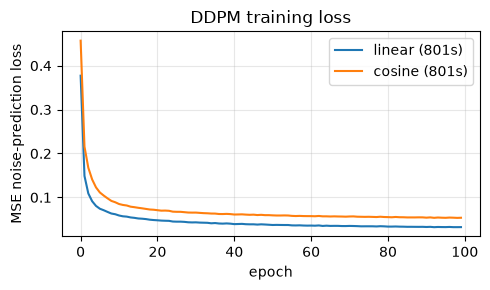

In [8]:
# Training-loss curves (near-identical, as expected: the schedule changes the
# noise distribution, not the per-step training cost).
plt.figure(figsize=(5, 3))
plt.plot(lin_hist, label=f"linear ({lin_time:.0f}s)")
plt.plot(cos_hist, label=f"cosine ({cos_time:.0f}s)")
plt.xlabel("epoch"); plt.ylabel("MSE noise-prediction loss")
plt.legend(); plt.grid(alpha=0.3); plt.title("DDPM training loss")
plt.tight_layout(); plt.show()

## Sanity grids (12 samples x 10 digits, full sampling steps)

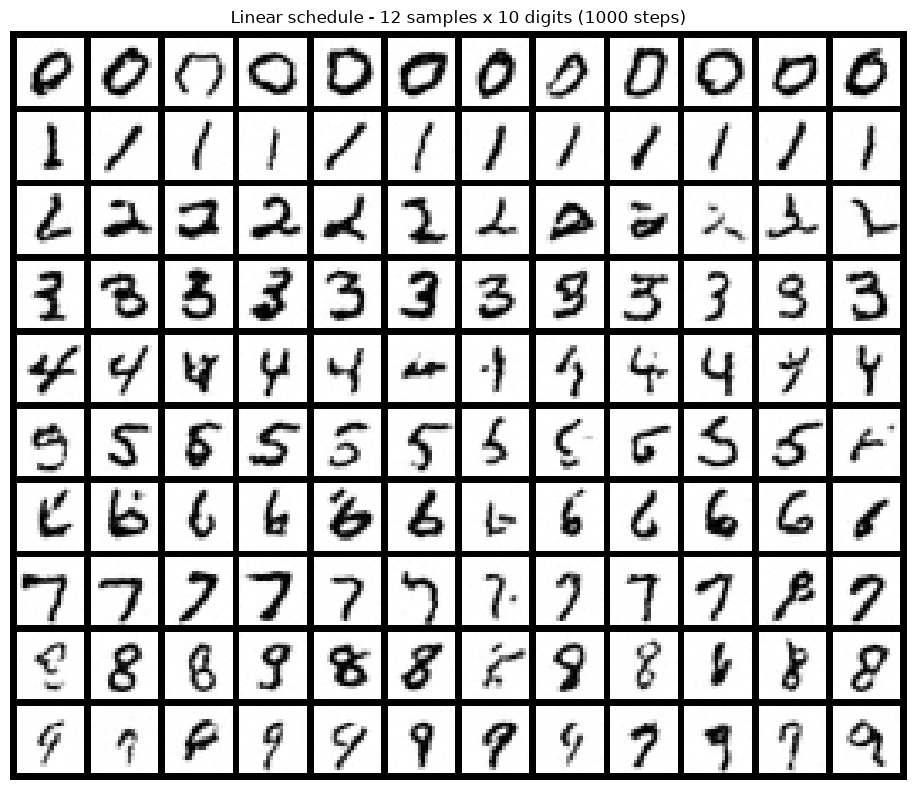

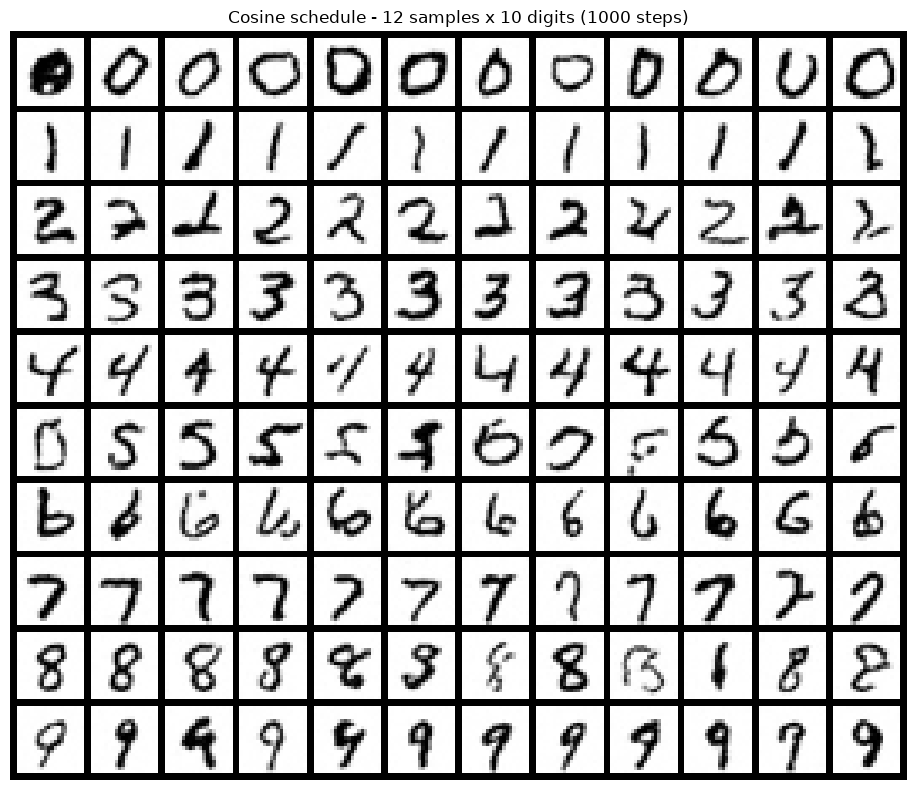

In [9]:
# Task-2 style sanity grids straight after training: 12 samples x 10 digits
# (120 images) for each schedule at full sampling steps.
for name, m, sch in [("Linear", lin_model, lin_sched), ("Cosine", cos_model, cos_sched)]:
    g = make_digit_grid(m, sch, samples_per_digit=12, num_steps=sch["T"])
    show_digit_grid(g, 12, f"{name} schedule - 12 samples x 10 digits ({sch['T']} steps)")
    torch.save(g, f"samples_{name.lower()}_full.pt")